In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 


# pd e uma convencao para importar a biblioteca pandas, que e usada para manipulacao de dados em Python.
df = pd.read_csv("data/retail_customer_churn_100k (1).csv")
# df porque é data frame
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  str    
 1   age_group              100000 non-null  str    
 2   gender                 100000 non-null  str    
 3   region                 100000 non-null  str    
 4   customer_segment       100000 non-null  str    
 5   preferred_channel      100000 non-null  str    
 6   purchase_frequency     100000 non-null  int64  
 7   avg_order_value        100000 non-null  float64
 8   total_spent            100000 non-null  float64
 9   recency_days           100000 non-null  int64  
 10  website_visits         100000 non-null  int64  
 11  discount_usage_rate    100000 non-null  float64
 12  email_open_rate        100000 non-null  float64
 13  cart_abandonment_rate  100000 non-null  float64
 14  loyalty_score          100000 non-null  int64  


,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,11.802220,209.704723,2543.890827,182.740540,58.524370,0.426245,0.474519,0.450982,54.61683,51.176860,0.462240
std,14.368458,109.710192,3790.838484,105.123047,78.797453,0.217042,0.245401,0.230493,25.96110,16.829141,0.498575
min,1.000000,20.030000,17.870000,1.000000,2.000000,0.050000,0.050000,0.050000,10.00000,10.000000,0.000000
25%,2.000000,114.610000,381.317500,92.000000,10.000000,0.240000,0.260000,0.250000,32.00000,39.000000,0.000000
50%,8.000000,209.485000,1089.180000,182.000000,29.000000,0.430000,0.470000,0.450000,55.00000,51.000000,0.000000
75%,12.000000,304.750000,2952.172500,274.000000,71.000000,0.610000,0.690000,0.650000,77.00000,63.000000,1.000000
max,60.000000,400.000000,28444.240000,364.000000,479.000000,0.800000,0.900000,0.850000,99.00000,92.000000,1.000000


In [3]:
 %pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df[df['age_group']=='18-24']

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,Medium,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,Low,0
8,C000009,18-24,Male,West,Loyal,In-Store,12,313.08,3290.78,231,70,0.74,0.77,0.41,42,68.0,Medium,1
10,C000011,18-24,Male,West,Loyal,Mobile App,2,117.31,202.75,207,9,0.07,0.14,0.08,61,53.0,Medium,0
12,C000013,18-24,Other,North,Returning,In-Store,8,132.34,939.00,284,54,0.19,0.81,0.48,98,66.5,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99982,C099983,18-24,Male,West,Loyal,Mobile App,5,286.96,1422.88,80,38,0.62,0.08,0.39,38,34.5,Low,0
99984,C099985,18-24,Male,South,New,Mobile App,35,308.12,9590.80,341,96,0.65,0.29,0.72,32,28.5,High,1
99990,C099991,18-24,Other,North,Returning,Online,20,84.13,1690.27,186,80,0.13,0.81,0.47,86,67.0,Medium,0
99992,C099993,18-24,Other,South,Returning,Online,12,113.72,1285.02,313,52,0.28,0.72,0.72,22,50.0,High,1


In [5]:
df['loyalty_score'].mean()
df.groupby('age_group')['loyalty_score'].mean()
df.groupby('age_group')['churn_flag'].sum()

age_group
18-24    9242
25-34    9146
35-44    9324
45-54    9265
55+      9247
Name: churn_flag, dtype: int64

In [6]:
df.groupby('churn_flag')['churn_flag'].count()

churn_flag
0    53776
1    46224
Name: churn_flag, dtype: int64

In [7]:
df.groupby('churn_flag')['loyalty_score'].mean()

churn_flag
0    58.834926
1    49.709588
Name: loyalty_score, dtype: float64

In [8]:
df.groupby('churn_flag')['purchase_frequency'].mean()

churn_flag
0    12.466342
1    11.029595
Name: purchase_frequency, dtype: float64

In [9]:
df.groupby('gender')['churn_flag'].mean()

gender
Female    0.462703
Male      0.463271
Other     0.460737
Name: churn_flag, dtype: float64

In [10]:
df.groupby('region')['churn_flag'].mean()

region
Central    0.464521
East       0.463636
North      0.463289
South      0.454610
West       0.464993
Name: churn_flag, dtype: float64

In [11]:
df.groupby('customer_segment')['churn_flag'].mean()

customer_segment
Loyal        0.459256
New          0.463186
Returning    0.459810
VIP          0.466715
Name: churn_flag, dtype: float64

In [12]:
df.groupby('preferred_channel')['churn_flag'].mean()

preferred_channel
In-Store      0.462571
Mobile App    0.457480
Online        0.466647
Name: churn_flag, dtype: float64

<Axes: xlabel='age_group', ylabel='churn_flag'>

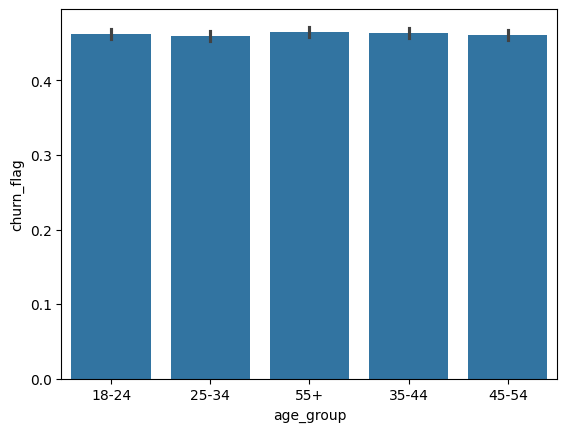

In [13]:
sns.barplot(data=df, x='age_group', y='churn_flag')

(0.0, 0.5)

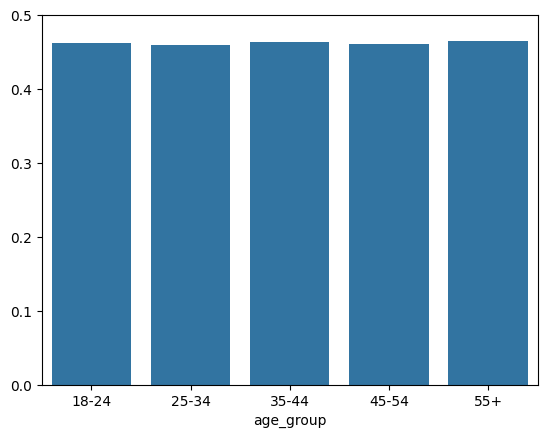

In [14]:
dados=df.groupby('age_group')['churn_flag'].mean()
sns.barplot(x=dados.index, y=dados.values)
plt.ylim(0,0.5)

(0.0, 1.0)

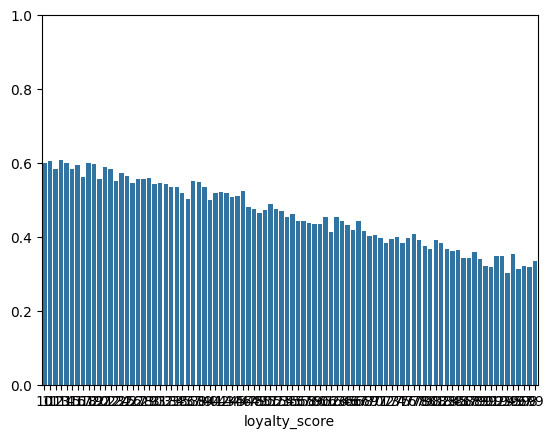

In [15]:
dados=df.groupby('loyalty_score')['churn_flag'].mean()
sns.barplot(x=dados.index, y=dados.values)
plt.ylim(0,1)

<Axes: xlabel='churn_flag', ylabel='loyalty_score'>

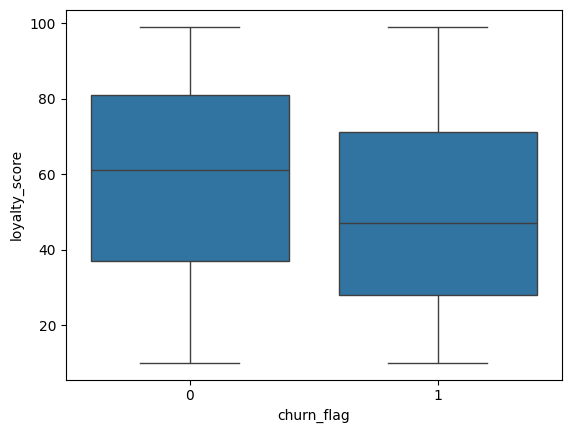

In [16]:
data=df.groupby('loyalty_score')['churn_flag'].mean() 
sns.boxplot(data=df, x='churn_flag', y='loyalty_score')

<Axes: xlabel='churn_risk'>

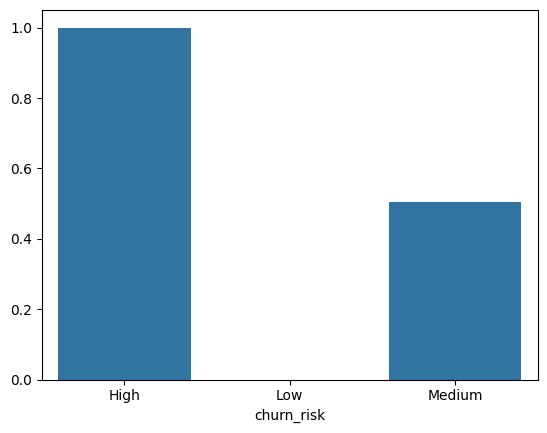

In [17]:
data=df.groupby('churn_risk')['churn_flag'].mean() 
sns.barplot(x=data.index, y=data.values)


In [18]:
df.corr(numeric_only=True)


,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_flag
purchase_frequency,1.000000,0.004561,0.822762,-0.001743,0.912442,0.005852,0.000301,0.000868,0.004925,-0.000375,-0.049854
avg_order_value,0.004561,1.000000,0.356315,-0.002742,0.003649,-0.001216,-0.002264,0.001431,0.003118,-0.002631,-0.004330
total_spent,0.822762,0.356315,1.000000,-0.001523,0.751104,0.005232,-0.001756,0.002216,0.005769,-0.002797,-0.042300
recency_days,-0.001743,-0.002742,-0.001523,1.000000,-0.002522,0.000842,0.001250,0.004663,0.003310,-0.002282,0.774030
website_visits,0.912442,0.003649,0.751104,-0.002522,1.000000,0.006467,-0.000578,0.001231,0.003757,-0.001265,-0.044094
discount_usage_rate,0.005852,-0.001216,0.005232,0.000842,0.006467,1.000000,0.006324,-0.004391,-0.005493,0.007618,0.001864
email_open_rate,0.000301,-0.002264,-0.001756,0.001250,-0.000578,0.006324,1.000000,0.000537,-0.002160,0.728728,0.002463
cart_abandonment_rate,0.000868,0.001431,0.002216,0.004663,0.001231,-0.004391,0.000537,1.000000,-0.001328,-0.684412,0.228116
loyalty_score,0.004925,0.003118,0.005769,0.003310,0.003757,-0.005493,-0.002160,-0.001328,1.000000,-0.000665,-0.175249
engagement_score,-0.000375,-0.002631,-0.002797,-0.002282,-0.001265,0.007618,0.728728,-0.684412,-0.000665,1.000000,-0.154419


<Axes: xlabel='churn_flag', ylabel='cart_abandonment_rate'>

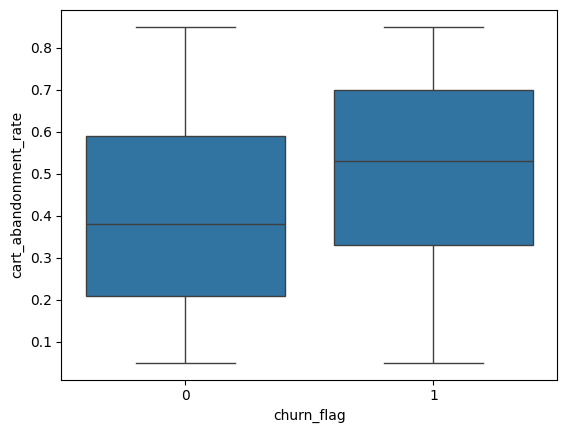

In [19]:
data=df.groupby('cart_abandonment_rate')['churn_flag'].mean() 
sns.boxplot(data=df, x='churn_flag', y='cart_abandonment_rate')


<Axes: xlabel='churn_flag', ylabel='recency_days'>

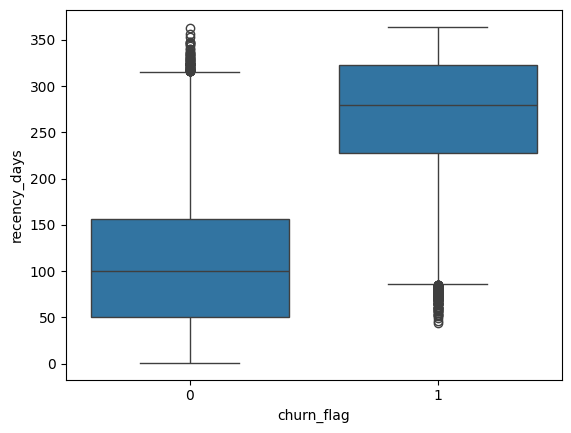

In [20]:
sns.boxplot(data=df, x='churn_flag', y='recency_days')

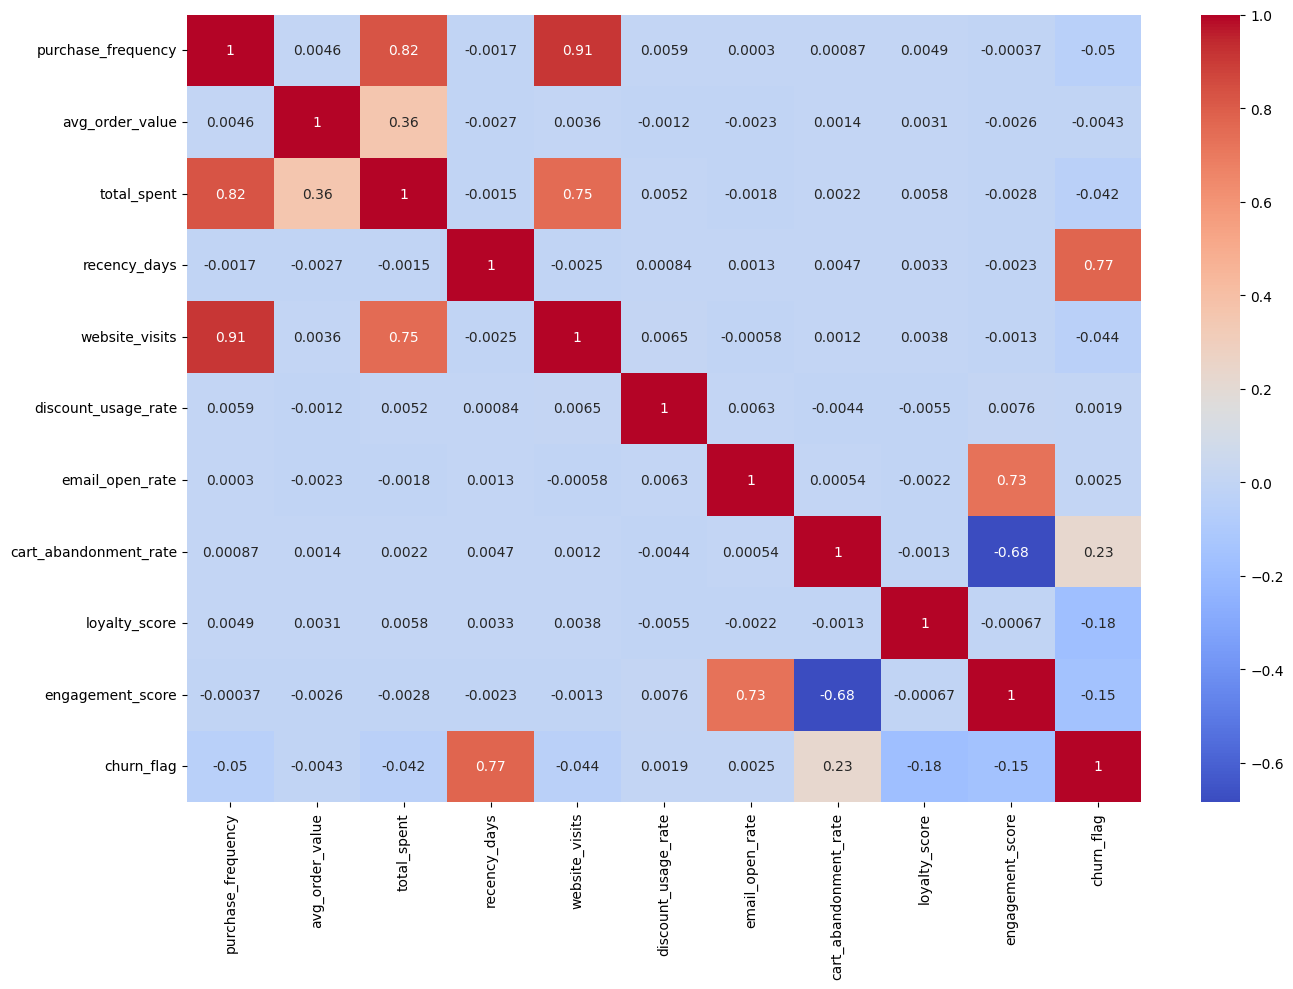

In [21]:
plt.figure(figsize=(14,10))
data= df.corr(numeric_only=True)
sns.heatmap(data, annot=True, cmap='coolwarm')
plt.tight_layout()

In [22]:
recursos = ['recency_days', 'cart_abandonment_rate', 'loyalty_score', 'engagement_score']

X = df[recursos]
Y = df['churn_flag']

X.head()

,recency_days,cart_abandonment_rate,loyalty_score,engagement_score
0,189,0.42,33,35.5
1,277,0.07,68,49.5
2,271,0.46,73,38.0
3,89,0.13,93,59.0
4,264,0.58,11,34.5


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print("Dados para treino:", X_train.shape[0])
print("Dados para teste:", X_test.shape[0])


Dados para treino: 70000
Dados para teste: 30000


In [24]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
modelo_podado = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Treinar o modelo podado com os dados de treino
modelo_podado.fit(X_train, y_train)

# 3. Fazer previsões usando as pistas de teste
previsoes_podadas = modelo_podado.predict(X_test)

# 4. Calcular a acurácia comparando o gabarito real com os palpites
acuracia_podada = accuracy_score(y_true=y_test,
y_pred=previsoes_podadas)

print(f"A acurácia da nossa árvore podada no teste foi de: {acuracia_podada * 100:.2f}%")

A acurácia da nossa árvore podada no teste foi de:89.91%


In [35]:
import pandas as pd

tabela_importancia = pd.DataFrame({'Pista (Variável)': X.columns, 'Importância (%)': modelo_arvore.feature_importances_ * 100})

tabela_importancia = tabela_importancia.sort_values(by='Importância (%)', ascending=False)

tabela_importancia

,Pista (Variável),Importância (%)
0,recency_days,69.020272
1,cart_abandonment_rate,13.536144
2,loyalty_score,11.656276
3,engagement_score,5.787308


In [29]:
print(f"Profundidade da árvore: {modelo_arvore.get_depth()} níveis")

previsoes_treino = modelo_arvore.predict(X_train)
acuracia_treino = accuracy_score(y_train, previsoes_treino)

print(f"Acurácia no Treino: {acuracia_treino * 100:.2f}%")

Profundidade da árvore: 25 níveis
Acurácia no Treino: 100.00%


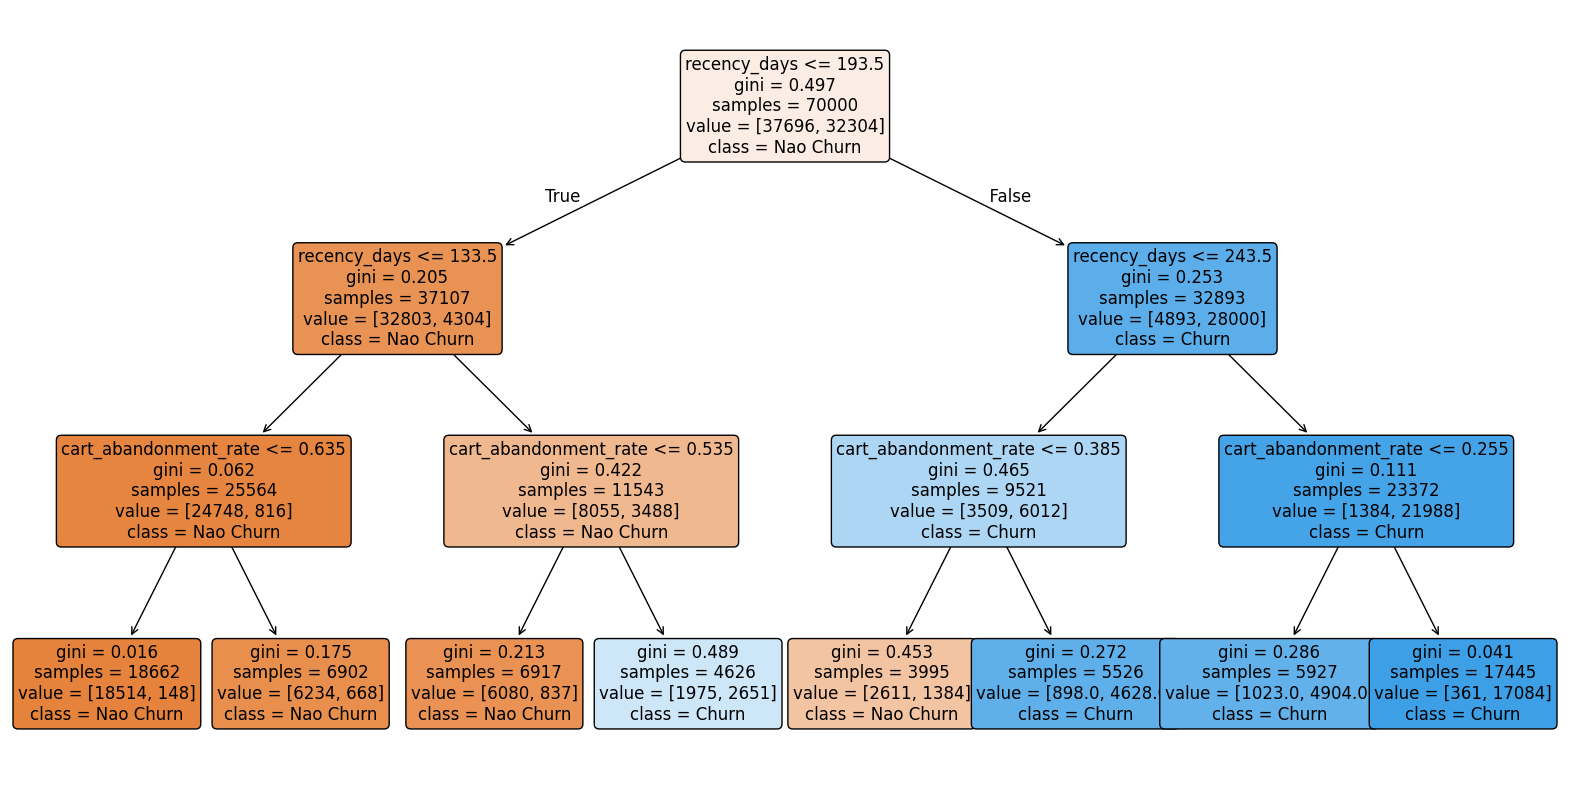

In [36]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(modelo_podado, feature_names=X.columns.tolist(), class_names=['Nao Churn', 'Churn'], filled=True, rounded=True, fontsize=12)

plt.show()


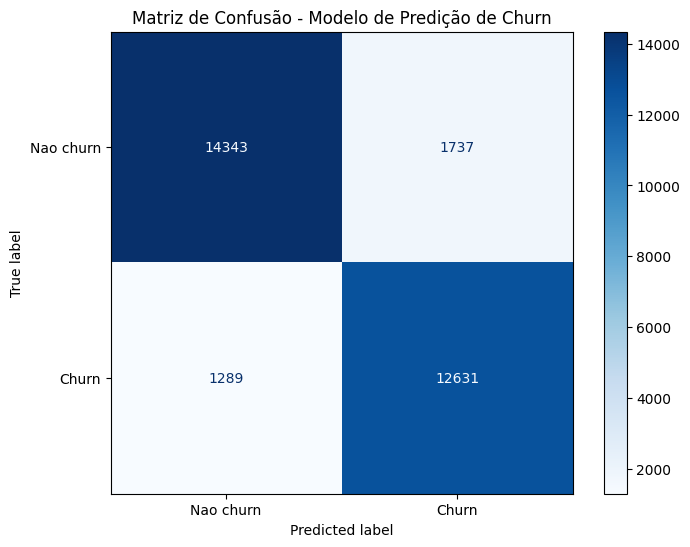

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt 

matriz = confusion_matrix(y_true=y_test, y_pred=previsoes_podadas)

visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Nao churn', 'Churn'])

fig, ax= plt.subplots(figsize=(8,6))
visualizacao.plot(ax=ax, cmap='Blues', values_format='d')

plt.title("Matriz de Confusão - Modelo de Predição de Churn")
plt.show()


In [39]:
from sklearn.metrics import classification_report

relatorio = classification_report(y_true=y_test, y_pred= previsoes_podadas, target_names=['Nao Churn', 'Churn'])

print(relatorio)

              precision    recall  f1-score   support

   Nao Churn       0.92      0.89      0.90     16080
       Churn       0.88      0.91      0.89     13920

    accuracy                           0.90     30000
   macro avg       0.90      0.90      0.90     30000
weighted avg       0.90      0.90      0.90     30000

